# 一.简介
逻辑回归(LogisticRegression)简单来看就是在线性回归模型外面再套了一个$Sigmoid$函数：
$$
\delta(t)=\frac{1}{1+e^{-t}}
$$
它的函数形状如下：

In [1]:
import sys
sys.path.append("/Users/brench/brench_project_collections/ML_Learning_Notes/ml_model_notebooks")
import numpy as np
from utils import utils
import matplotlib.pyplot as plt
%matplotlib inline

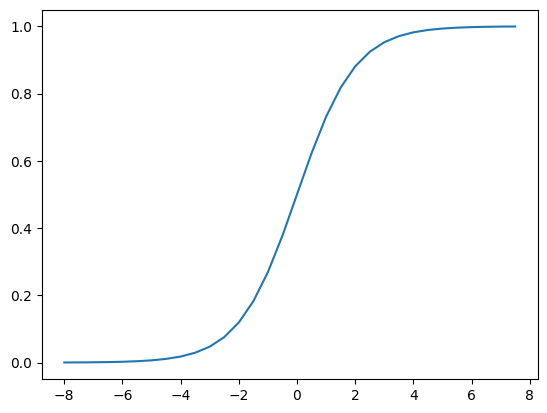

In [2]:
t = np.arange(-8,8,0.5)
d_t = 1/(1 + np.exp(-t))
plt.plot(t, d_t)

而将$t$替换为线性回归模型$w^Tx^*$（这里$x^*=[x^T,1]^T$）即可得到逻辑回归模型：
$$
f(x)=\delta(w^Tx^*)=\frac{1}{1+e^{-(w^Tx^*)}}
$$
我们可以发现：
$Sigmoid$函数决定了模型的输出在$(0,1)$区间，所以逻辑回归模型可以用作区间在$(0,1)$的回归任务，也可以用作$\{0,1\}$的二分类任务；同样，由于模型的输出在$(0,1)$区间，所以逻辑回归模型的输出也可以看作这样的“概率”模型：
$$
P(y=1\mid x)=f(x)\\
P(y=0\mid x)=1-f(x)
$$
所以，逻辑回归的学习目标可以通过极大似然估计求解：
$\prod_{j=1}^n f(x_j)^{y_j}(1-f(x_j))^{(1-y_j)}$，即使得观测到的当前所有样本的所属类别概率尽可能大；通过对该函数取负对数，即可得到交叉熵损失函数：
$$
L(w)=-\sum_{j=1}^n y_j log(f(x_j))+(1-y_j)log(1-f(x_j))
$$
这里$n$表示样本量，$x_j\in R^m$，$m$表示特征量，$y_j\in \{0,1\}$，接下来的与之前推导一样，通过梯度下降求解$w$的更新公式即可：
$$
\frac{\partial L}{\partial w}=-\sum_{i=1}^n (y_i-f(x_i))x_i^*
$$
所以$w$的更新公式：
$$
w:=w-\eta \frac{\partial L}{\partial w}
$$


# 二.代码实现
同LinearRegression类似，这里也将$L1,L2$的正则化功能加入

In [126]:
class LogisticRegression(object):
    """线性回归模型实现

    该类实现了线性回归算法，支持配置是否拟合截距项、选择优化器、
    特征标准化处理等功能，通过迭代优化方法求解模型参数。
    """
    def __init__(self, fit_intercept = True, optimizer = 'sgd', if_standard = True,
                 epochs = 100, lr = 1e-2, batch_size = 16, l1_ratio = None, l2_ratio = None):
        """初始化线性回归模型参数

        :param fit_intercept: bool类型，可选，默认值为True
            是否在模型中拟合截距项（偏置项）。若为True，模型会额外学习一个常数项；
            若为False，模型仅学习特征的系数，不包含截距项。

        :param optimizer: str类型，可选，默认值为'sgd'
            模型训练使用的优化器名称。目前默认支持'sgd'（随机梯度下降），
            可扩展支持其他优化器（如'gd'梯度下降、'momentum'动量法等）。

        :param if_standard: bool类型，可选，默认值为True
            是否对输入特征进行标准化处理。若为True，训练过程中会计算每个特征的均值和标准差，
            并将特征转换为均值为0、标准差为1的标准化特征；若为False，则不进行标准化。

        :param epochs: int类型，可选，默认值为10
            训练迭代的轮数（完整遍历训练集的次数）。轮数越多，模型在训练集上的迭代次数越多，
            需注意避免过拟合，通常需要根据验证集性能调整。

        :param lr: float类型，可选，默认值为1e-2（即0.01）
            学习率（步长），控制优化过程中参数更新的幅度。学习率过大会导致收敛不稳定，
            过小则会延长训练时间，需根据实际场景调整（通常为0.001~0.1之间）。

        :param batch_size: int类型，可选，默认值为1
            每次参数更新使用的样本批量大小。当为1时，为随机梯度下降（SGD）；
            当等于训练集大小时，为批量梯度下降（BGD）；当为1~训练集大小之间时，
            为小批量梯度下降（MBGD）。需为正整数，且不超过训练样本总数。

        :ivar w: 模型参数（系数），初始化为None，训练后存储特征对应的权重
        :ivar feature_mean: 特征均值，当if_standard为True时有效，存储各特征的均值
        :ivar feature_std: 特征标准差，当if_standard为True时有效，存储各特征的标准差
        """
        self.w = None
        self.fit_intercept = fit_intercept
        self.optimizer = optimizer
        self.if_standard = if_standard
        if if_standard:
            self.feature_mean = None
            self.feature_std = None
        self.epochs = epochs
        self.eta = lr
        self.batch_size = batch_size
        self.l1_ratio = l1_ratio
        self.l2_ratio = l2_ratio
        # 注册sign函数
        self.sign_func = np.vectorize(utils.sign)
        # 记录losses
        self.losses = []

    def init_params(self, n_features):
        """初始化模型参数（权重矩阵）

        该方法根据输入特征的数量，使用随机数初始化模型的权重参数w，
        生成形状为(n_features, 1)的初始权重矩阵，为后续模型训练做准备。

        :param n_features: int类型，正整数
            输入特征的数量（特征维度）。决定了权重矩阵的行数，需与训练数据的特征维度一致。

        :return: None
            无返回值，初始化结果直接存储在实例变量self.w中。

        :ivar self.w: numpy数组，形状为(n_features, 1)
            初始化后的值为[0, 1)区间内的随机浮点数，存储模型的特征权重参数。
        """
        self.w = np.random.random(size = (n_features, 1))


    def _fit_closed_form_solution(self, x, y):
        """
        直接求闭式解
        :param x:
        :param y:
        :return:
        """
        if self.l1_ratio is None and self.l2_ratio is None:
            self.w = np.linalg.pinv(x).dot(y)
        elif self.l1_ratio is None and self.l2_ratio is not None:
            self.w = np.linalg.inv(x.T.dot(x) + self.l2_ratio * np.eye(x.shape[1])).dot(x.T).dot(y)
        else:
            self._fit_sgd(x, y)

    def _fit_sgd(self, x, y):
        """
        随机梯度下降求解
        :param x:
        :param y:
        :param epochs:
        :param eta:
        :param batch_size:
        :return:
        """
        x_y = np.c_[x, y]
        count = 0
        for _ in range(self.epochs):
            np.random.shuffle(x_y)
            for index in range(x_y.shape[0] // self.batch_size):
                count += 1
                batch_x_y = x_y[self.batch_size * index:self.batch_size * (index + 1)]
                batch_x = batch_x_y[:, :-1]
                batch_y = batch_x_y[:, -1:]

                dw = -1 * (batch_y - utils.sigmoid(batch_x.dot(self.w))).T.dot(batch_x) / self.batch_size
                dw = dw.T

                # 添加l1和l2的部分
                dw_reg = np.zeros(shape=(x.shape[1] - 1, 1))
                if self.l1_ratio is not None:
                    dw_reg += self.l1_ratio * self.sign_func(self.w[:-1]) / self.batch_size
                if self.l2_ratio is not None:
                    dw_reg += 2 * self.l2_ratio * self.w[:-1] / self.batch_size
                dw_reg = np.concatenate([dw_reg, np.asarray([[0]])], axis=0)

                dw += dw_reg
                self.w = self.w - self.eta * dw

            # 计算losses
            cost = -1 * np.sum(
                np.multiply(y, np.log(utils.sigmoid(x.dot(self.w)))) + np.multiply(1 - y, np.log(
                    1 - utils.sigmoid(x.dot(self.w)))))
            self.losses.append(cost)

    def fit(self, x, y):
        # 是否归一化feature
        if self.if_standard:
            self.feature_mean = np.mean(x, axis=0)
            self.feature_std = np.std(x, axis=0) + 1e-8
            x = (x - self.feature_mean) / self.feature_std
        # 是否训练bias
        if self.fit_intercept:
            x = np.c_[x, np.ones_like(y)]
        # 初始化参数
        self.init_params(x.shape[1])
        # 训练模型
        if self.optimizer == 'closed_form':
            self._fit_closed_form_solution(x, y)
        elif self.optimizer == 'sgd':
            self._fit_sgd(x, y)

    def get_params(self):
        """
        输出原始的系数
        :return: w,b
        """
        if self.fit_intercept:
            w = self.w[:-1]
            b = self.w[-1]
        else:
            w = self.w
            b = 0
        if self.if_standard:
            w = w / self.feature_std.reshape(-1, 1)
            b = b - w.T.dot(self.feature_mean.reshape(-1, 1))
        return w.reshape(-1), b

    def predict_proba(self, x):
        """
        预测为y=1的概率
        :param x: nd.array格式数据: `m x n`
        :return: `m x 1`
        """
        if self.if_standard:
            x = (x - self.feature_mean) / self.feature_std
        if self.fit_intercept:
            x = np.c_[x, np.ones(x.shape[0])]
        return utils.sigmoid(x.dot(self.w))

    def predict(self, x):
        """
        预测类别，默认大于0.5的为1，小于0.5的为0
        :param x:
        :return:
        """
        proba = self.predict_proba(x)
        return (proba > 0.5).astype(int)

    def plot_fit_boundary(self, x, y):
        """
        绘制拟合结果
        :param x:
        :param y:
        :return:
        """
        plt.scatter(x[:, 0], y)
        plt.plot(x[:, 0], self.predict(x), 'r')


    def plot_decision_boundary(self, x, y):
        """
        绘制前两个维度的决策边界
        :param x:
        :param y:
        :return:
        """
        y = y.reshape(-1)
        weights, bias = self.get_params()
        w1 = weights[0]
        w2 = weights[1]
        bias = bias[0][0]
        x1 = np.arange(np.min(x), np.max(x), 0.1)
        x2 = -w1 / w2 * x1 - bias / w2
        plt.scatter(x[:, 0], x[:, 1], c=y, s=50)
        plt.plot(x1, x2, 'r')
        plt.show()

    def plot_losses(self):
        plt.plot(range(0, len(self.losses)), self.losses)
        plt.show()

# 三.校验
这里我们构造一批伪分类数据并可视化

In [153]:
from sklearn.datasets import make_classification
data,target = make_classification(
    n_samples = 100,
    n_features = 2,
    n_classes = 2,
    n_informative = 1,
    n_redundant = 0,
    n_repeated = 0,
    n_clusters_per_class = 1
)

In [154]:
data.shape,target.shape

((100, 2), (100,))

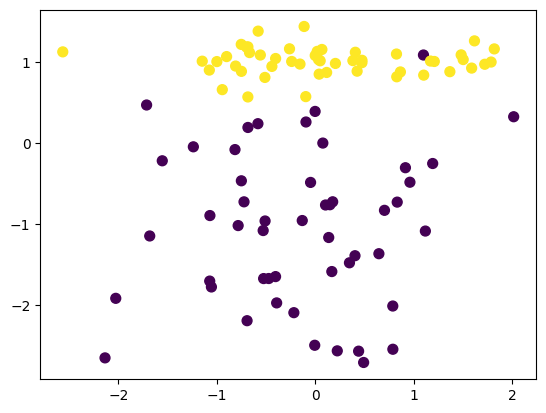

In [155]:
plt.scatter(data[:, 0], data[:, 1], c = target, s = 50)

训练模型

In [156]:
logistic_regression = LogisticRegression(l1_ratio = 0.01,l2_ratio = 0.01)
logistic_regression.fit(data, target)

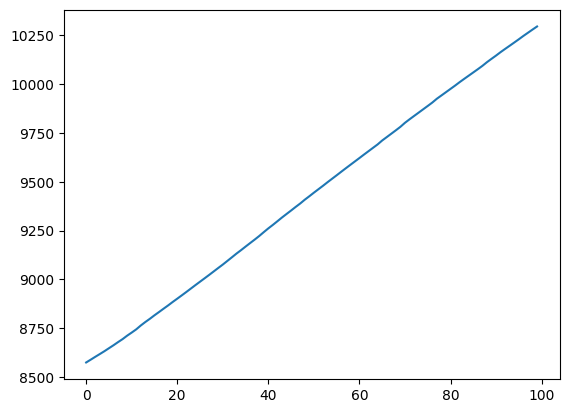

In [157]:
logistic_regression.plot_losses()

## 绘制决策边界：
令$w_1x_1+w_2x_2+b=0$，可得$x_2=-\frac{w_1}{w_2}x_1-\frac{b}{w_2}$

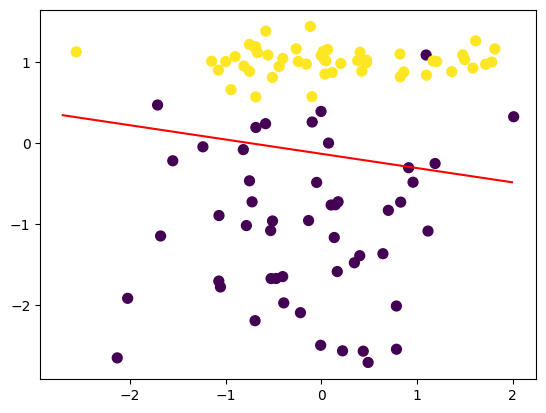

In [158]:
logistic_regression.plot_decision_boundary(data, target)

In [159]:
#计算F1
from sklearn.metrics import f1_score
f1_score(target, logistic_regression.predict(data))

0.9174311926605505

和 sklearn 官方库做对比

In [160]:
from sklearn.linear_model import LogisticRegression

In [161]:
logistic_regression_sklearn = LogisticRegression()
logistic_regression_sklearn.fit(data, target)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [162]:
w1 = logistic_regression_sklearn.coef_[0][0]
w2 = logistic_regression_sklearn.coef_[0][1]
bias = logistic_regression_sklearn.intercept_[0]
w1, w2, bias

(0.051100350931788906, 3.3428536769811363, -1.1221154382126302)

In [163]:
x1 = np.arange(np.min(data), np.max(data), 0.1)
x2 = -w1/w2*x1-bias/w2

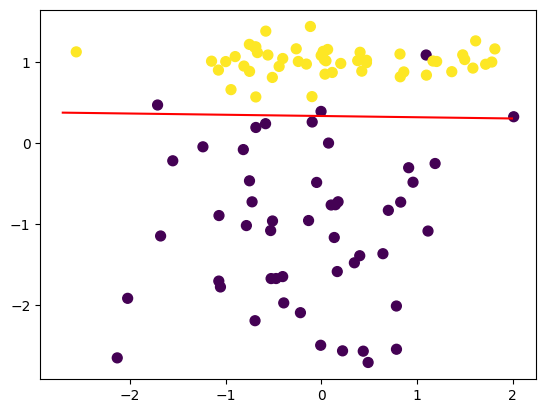

In [164]:
plt.scatter(data[:, 0], data[:, 1], c = target, s = 50)
plt.plot(x1, x2, 'r')

In [165]:
#计算F1
f1_score(target, logistic_regression_sklearn.predict(data))

0.9615384615384616

# 四.问题讨论：损失函数为何不用mse?
上面基本完成了二分类LogisticRegression代码的封装工作，并将其放到liner_model模块方便后续使用，接下来讨论一下模型中损失函数选择的问题；在前面线性回归模型中使用了mse作为损失函数，并取得了不错的效果，而逻辑回归中使用的确是交叉熵损失函数；这是因为如果使用mse作为损失函数,梯度下降将会比较困难，在$f(x^i)$与$y^i$相差较大或者较小时梯度值都会很小，下面推导一下：
我们令：
$$
L(w)=\frac{1}{2}\sum_{i=1}^n(y^i-f(x^i))^2
$$
则有：
$$
\frac{\partial L}{\partial w}=\sum_{i=1}^n(f(x^i)-y^i)f(x^i)(1-f(x^i))x^i
$$
简单看两个极端的情况：
（1）$y^i=0,f(x^i)=1$时，$\frac{\partial L}{\partial w}=0$；
（2）$y^i=1,f(x^i)=0$时，$\frac{\partial L}{\partial w}=0$
接下来，绘图对比一下两者梯度变化的情况，假设在$y=1,x\in(-10,10),w=1,b=0$的情况下